In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.compose import make_column_selector
from sklearn.model_selection import cross_val_predict
from sklearn.base import clone
from sklearn.metrics import roc_curve, precision_recall_curve

Get Data


In [46]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', as_frame=False) 

X, y = mnist.data, mnist.target
X_train, y_train = X[:30000], y[:30000]
y_train_5 = y_train == '5'

Test SGDClassifier

In [47]:
sgd_clf = SGDClassifier(random_state=42)

grid = {
    'loss': ['hinge', 'log_loss'],
    'alpha': [0.01, 1, 10],
    'learning_rate': ['optimal'],
}

scoring = {
    'AUC': 'roc_auc',
    'F1': 'f1',
    'Precision': 'precision',
    'Recall': 'recall'
}

sgd_clf_search = GridSearchCV(sgd_clf, grid, cv=3, scoring=scoring, refit='F1')
sgd_clf_search.fit(X_train, y_train_5)

,estimator,SGDClassifier(random_state=42)
,param_grid,"{'alpha': [0.01, 1, ...], 'learning_rate': ['optimal'], 'loss': ['hinge', 'log_loss']}"
,scoring,"{'AUC': 'roc_auc', 'F1': 'f1', 'Precision': 'precision', 'Recall': 'recall'}"
,n_jobs,None
,refit,'F1'
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [49]:
results = pd.DataFrame(sgd_clf_search.cv_results_)
params = pd.DataFrame(results['params'].tolist())
cols = ['mean_test_Recall', 'mean_test_Precision', 'mean_test_F1', 'mean_test_AUC']

table = params.join(results[cols]).sort_values('mean_test_F1', ascending=False)
table

,alpha,learning_rate,loss,mean_test_Recall,mean_test_Precision,mean_test_F1,mean_test_AUC
5,10.00,optimal,log_loss,0.782207,0.888366,0.830842,0.974741
4,10.00,optimal,hinge,0.771133,0.898766,0.827641,0.971420
2,1.00,optimal,hinge,0.823551,0.820186,0.817949,0.972566
1,0.01,optimal,log_loss,0.793282,0.812491,0.799432,0.968859
0,0.01,optimal,hinge,0.875969,0.705533,0.773427,0.971158
3,1.00,optimal,log_loss,0.775932,0.799840,0.765196,0.971828


Plot roc/curve


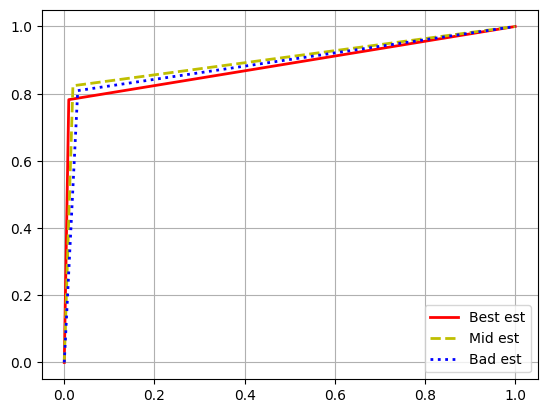

In [55]:
sgd_best_est = sgd_clf_search.best_estimator_
y_score_best = cross_val_predict(sgd_best_est, X_train, y_train_5, cv=3)
fpr_b, tpr_b, thresholds_b = roc_curve(y_train_5, y_score_best)

sgd_row_2_est = clone(sgd_clf)
sgd_row_2_est.learning_rate = 'optimal'
sgd_row_2_est.alpha = 1
sgd_row_2_est.loss = 'hinge'

y_score_row_2 = cross_val_predict(sgd_row_2_est, X_train, y_train_5, cv=3)
fpr_2, tpr_2, thresholds_2 = roc_curve(y_train_5, y_score_row_2)

sgd_row_0_est = clone(sgd_clf)
sgd_row_0_est.learning_rate = 'optimal'
sgd_row_0_est.alpha = 0.1
sgd_row_0_est.loss = 'log_loss'

y_score_row_0 = cross_val_predict(sgd_row_0_est, X_train, y_train_5, cv=3)
fpr_0, tpr_0, thresholds_0 = roc_curve(y_train_5, y_score_row_0)

plt.plot(fpr_b, tpr_b, 'r-', linewidth=2, label="Best est")
plt.plot(fpr_2, tpr_2, 'y--', linewidth=2, label="Mid est")
plt.plot(fpr_0, tpr_0, 'b:', linewidth=2, label="Bad est")
plt.legend()
plt.grid()
plt.show()

Plot precision/recall

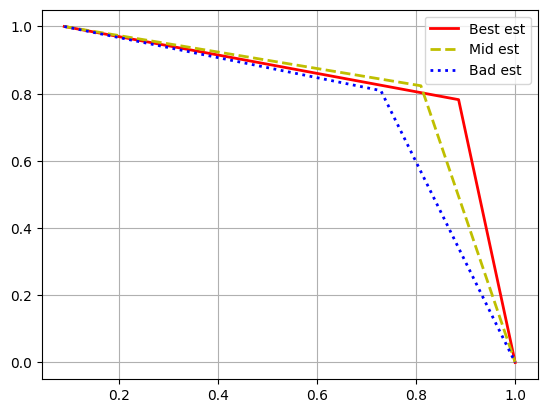

In [56]:
precision_b, recall_b, thresholds_b = precision_recall_curve(y_train_5, y_score_best)
precision_2, recall_2, thresholds_2 = precision_recall_curve(y_train_5, y_score_row_2)
precision_0, recall_0, thresholds_0 = precision_recall_curve(y_train_5, y_score_row_0)

plt.plot(precision_b, recall_b, 'r-', linewidth=2, label="Best est")
plt.plot(precision_2, recall_2, 'y--', linewidth=2, label="Mid est")
plt.plot(precision_0, recall_0, 'b:', linewidth=2, label="Bad est")
plt.legend()
plt.grid()
plt.show()

Test RandomForestClassifier

In [53]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],       
    'max_depth': [None, 10],          
    'max_features': ['sqrt', 'log2'],
}


forest_clf_search = GridSearchCV(forest_clf, param_grid, cv=3, scoring=scoring, refit='F1')
forest_clf_search.fit(X_train, y_train_5)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10], 'max_features': ['sqrt', 'log2'], 'n_estimators': [100, 200]}"
,scoring,"{'AUC': 'roc_auc', 'F1': 'f1', 'Precision': 'precision', 'Recall': 'recall'}"
,n_jobs,None
,refit,'F1'
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [54]:
results = pd.DataFrame(forest_clf_search.cv_results_)
params = pd.DataFrame(results['params'].tolist())
cols = ['mean_test_Recall', 'mean_test_Precision', 'mean_test_F1', 'mean_test_AUC']

table = params.join(results[cols]).sort_values('mean_test_F1', ascending=False)
table

,max_depth,max_features,n_estimators,mean_test_Recall,mean_test_Precision,mean_test_F1,mean_test_AUC
1,NaN,sqrt,200,0.842746,0.989988,0.910436,0.997808
0,NaN,sqrt,100,0.841639,0.988672,0.909205,0.997682
3,NaN,log2,200,0.771502,0.992847,0.868174,0.997864
2,NaN,log2,100,0.764120,0.992791,0.863463,0.997607
4,10.0,sqrt,100,0.765227,0.988540,0.862484,0.996790
5,10.0,sqrt,200,0.759690,0.988447,0.858885,0.997061
7,10.0,log2,200,0.592470,0.995048,0.742079,0.996388
6,10.0,log2,100,0.591731,0.995690,0.741779,0.996005


Plot roc/curve

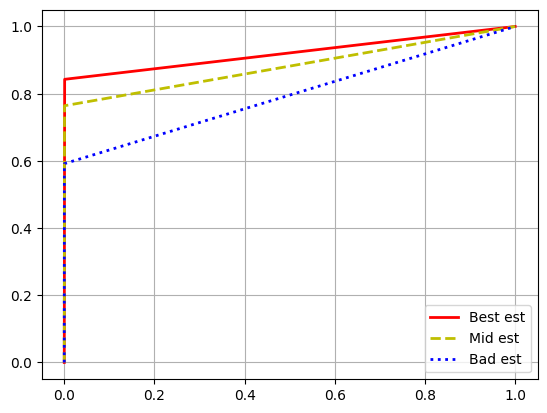

In [60]:
forest_best_est = forest_clf_search.best_estimator_
y_score_best = cross_val_predict(forest_best_est, X_train, y_train_5, cv=3)
fpr_b, tpr_b, thresholds_b = roc_curve(y_train_5, y_score_best)

forest_row_2_est = clone(forest_clf)
forest_row_2_est.max_depth = None
forest_row_2_est.max_features = 'log2'
forest_row_2_est.n_estimators = 100

y_score_row_2 = cross_val_predict(forest_row_2_est, X_train, y_train_5, cv=3)
fpr_2, tpr_2, thresholds_2 = roc_curve(y_train_5, y_score_row_2)

forest_row_6_est = clone(forest_clf)
forest_row_6_est.max_depth = 10
forest_row_6_est.max_features = 'log2'
forest_row_6_est.n_estimators = 100

y_score_row_6 = cross_val_predict(forest_row_6_est, X_train, y_train_5, cv=3)
fpr_6, tpr_6, thresholds_6 = roc_curve(y_train_5, y_score_row_6)

plt.plot(fpr_b, tpr_b, 'r-', linewidth=2, label="Best est")
plt.plot(fpr_2, tpr_2, 'y--', linewidth=2, label="Mid est")
plt.plot(fpr_6, tpr_6, 'b:', linewidth=2, label="Bad est")
plt.legend()
plt.grid()
plt.show()

Plot precision/recall

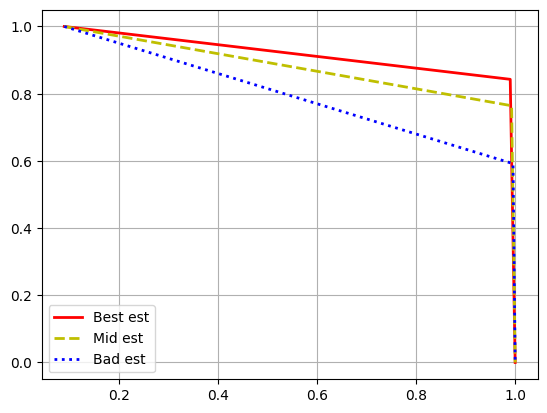

In [61]:
precision_b, recall_b, thresholds_b = precision_recall_curve(y_train_5, y_score_best)
precision_2, recall_2, thresholds_2 = precision_recall_curve(y_train_5, y_score_row_2)
precision_6, recall_6, thresholds_6 = precision_recall_curve(y_train_5, y_score_row_6)

plt.plot(precision_b, recall_b, 'r-', linewidth=2, label="Best est")
plt.plot(precision_2, recall_2, 'y--', linewidth=2, label="Mid est")
plt.plot(precision_6, recall_6, 'b:', linewidth=2, label="Bad est")
plt.legend()
plt.grid()
plt.show()